**Цель работы:**

Изучение связи между признаками двумерного набора данных, визуализация данных.

#### Описание предметной области

Вариант №5

Набор данных: `visits_cleaned.csv` — предварительно обработанные данные пользовательских сессий интернет-магазина.

Атрибуты:
- `user_id`: уникальный идентификатор пользователя
- `region`: страна пользователя
- `device`: устройство пользователя
- `channel`: идентификатор рекламного источника
- `session_start`: дата и время начала сессии
- `session_end`: дата и время окончания сессии
- `time_session`: длительность сессии (мин)
- `click_count`: количество кликов
- `buy_count`: количество покупок
- `price`: сумма покупок
- `age`: возраст пользователя

#### 1 – Загрузка и предварительный анализ данных

Для выполнения работы был использован набор данных `visits_cleaned.csv`, содержащий информацию о пользовательских сессиях интернет-магазина. Данные включают уникальный идентификатор пользователя, страну, тип устройства, канал привлечения, время начала и конца сессии, а также метрики активности (клики, покупки, сумма, возраст).

Была произведена загрузка данных с помощью библиотеки pandas. Поскольку данные уже прошли предварительную очистку в рамках первой лабораторной работы (замена пропусков, нормализация названий устройств и регионов, приведение типов), повторная глубокая очистка не требовалась. Типы не хранятся в csv, поэтому их нужно задать явно при чтении файла.


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Загрузка данных
df = pd.read_csv(
    'visits_cleaned.csv',
    sep=';',
    dtype={'user_id': str},
    parse_dates=['session_start', 'session_end']
)

print(df.info())
print(df.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 954 entries, 0 to 953
Data columns (total 11 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   user_id        954 non-null    object        
 1   region         954 non-null    object        
 2   device         954 non-null    object        
 3   channel        954 non-null    object        
 4   session_start  954 non-null    datetime64[ns]
 5   session_end    954 non-null    datetime64[ns]
 6   time_session   954 non-null    float64       
 7   click_count    954 non-null    int64         
 8   buy_count      954 non-null    int64         
 9   price          954 non-null    float64       
 10  age            954 non-null    int64         
dtypes: datetime64[ns](2), float64(2), int64(3), object(4)
memory usage: 82.1+ KB
None
                       session_start                    session_end  \
count                            954                            954   
mea

#### 2 – Точечные диаграммы и матрица рассеяния

Для выявления взаимосвязей между числовыми признаками была построена матрица диаграмм рассеяния (pairplot). Так как признаков много, для наглядности были выбраны ключевые метрики: `time_session` (длительность), `click_count` (клики), `buy_count` (покупки), `price` (сумма) и `age` (возраст).

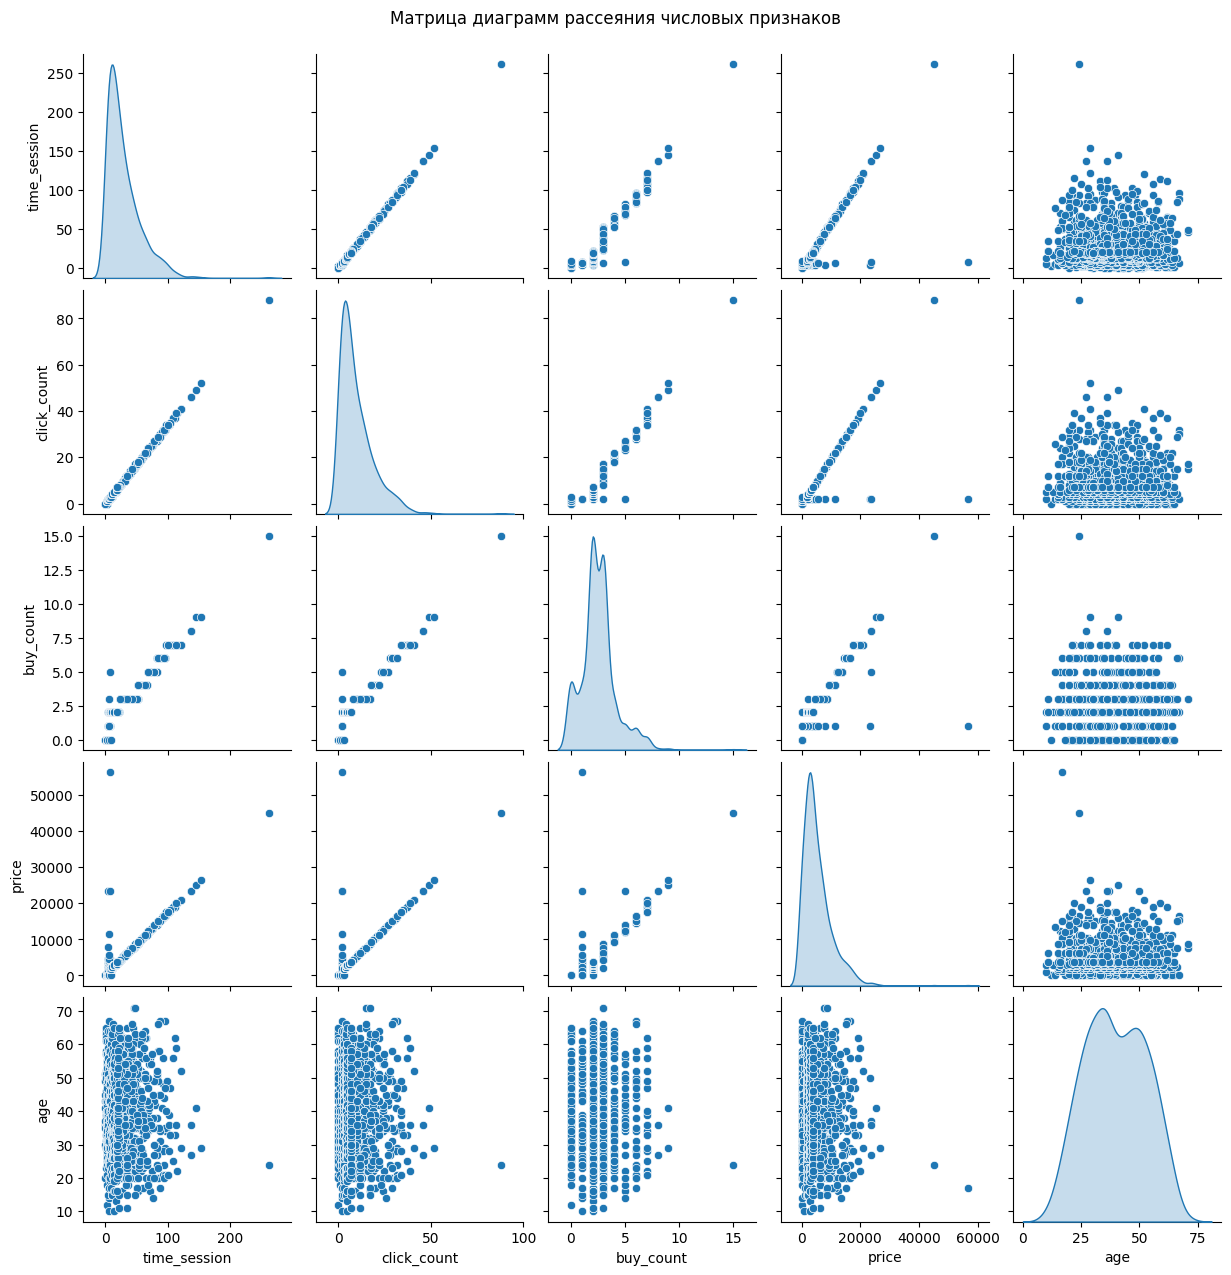

In [3]:
# Выбор числовых колонок для анализа
numeric_cols = ['time_session', 'click_count', 'buy_count', 'price', 'age']
df_numeric = df[numeric_cols].dropna()

# Построение матрицы рассеяния
sns.pairplot(df_numeric, diag_kind='kde')
plt.suptitle('Матрица диаграмм рассеяния числовых признаков', y=1.02)
plt.show()

In [6]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
import numpy as np

# Проверка тождественности time_session и разности session_end - session_start
df['calc_time'] = (df['session_end'] - df['session_start']).dt.total_seconds() / 60

# Количество расхождений
mismatches = (df['time_session'] != df['calc_time']).sum()
print(f"Расхождений между time_session и (session_end - session_start): {mismatches} из {len(df)} строк")

# Корреляция для подтверждения
r = df['time_session'].corr(df['calc_time'])
print(f"Коэффициент корреляции Пирсона: r = {r:.6f}")

# Очистка временного столбца
df.drop(columns=['calc_time'], inplace=True)

# Подготовка данных
X = df[['click_count']]
y = df['time_session']

# Обучение модели
model = LinearRegression().fit(X, y)

# Вывод результатов
print(f"Уравнение регрессии: time_session = {model.coef_[0]:.3f} * click_count + {model.intercept_:.3f}")
print(f"Остаточное среднеквадратичное отклонение (RMSE): {np.sqrt(mean_squared_error(y, model.predict(X))):.2f} мин")

Расхождений между time_session и (session_end - session_start): 0 из 954 строк
Коэффициент корреляции Пирсона: r = 1.000000
Уравнение регрессии: time_session = 2.944 * click_count + 0.123
Остаточное среднеквадратичное отклонение (RMSE): 1.13 мин



---

**Вывод:**
Числовые признаки связаны между собой **сильной** положительной линейной зависимостью (r = 0.87…0.999), а не слабой, как могло показаться по отдельным диаграммам рассеяния:

* `time_session` ↔ `click_count` — **r = 0.999** (максимальная связь в матрице);
* `click_count` ↔ `buy_count` — r = 0.949;
* `time_session` ↔ `buy_count` — r = 0.946;
* `click_count` ↔ `price` и `time_session` ↔ `price` — r = 0.905;
* `buy_count` ↔ `price` — r = 0.874;
* `age` — со всеми остальными признаками |r| ≤ 0.055, то есть связь отсутствует.

Причина столь плотной связи между `time_session` и `click_count` была проверена дополнительно: `time_session` **тождественно** равен разности `session_end - session_start` в минутах (расхождений 0 из 954 строк, r = 1.000000), а регрессия `time_session = 2.944 · click_count + 0.123` даёт остаточное среднеквадратичное отклонение всего 1.13 мин. То есть длительность сессии в этом наборе не измерена, а получена из числа кликов — примерно 3 минуты на клик. Эти два признака дублируют друг друга.

Практическое следствие — выраженная мультиколлинеарность: R² для `click_count` → `buy_count` = 0.90, `time_session` → `price` = 0.82, `buy_count` → `price` = 0.76. Использовать эти признаки одновременно в линейной модели нельзя, коэффициенты будут неинтерпретируемы.

Диагональ матрицы (KDE) показывает, что распределения `time_session`, `click_count`, `buy_count` и `price` правосторонне скошены, а распределение `age` близко к нормальному.

---

Также было построено точечное распределение зависимости стоимости покупок от возраста с разделением по типу устройства (категориальный признак), чтобы выполнить требование по визуализации категорий.

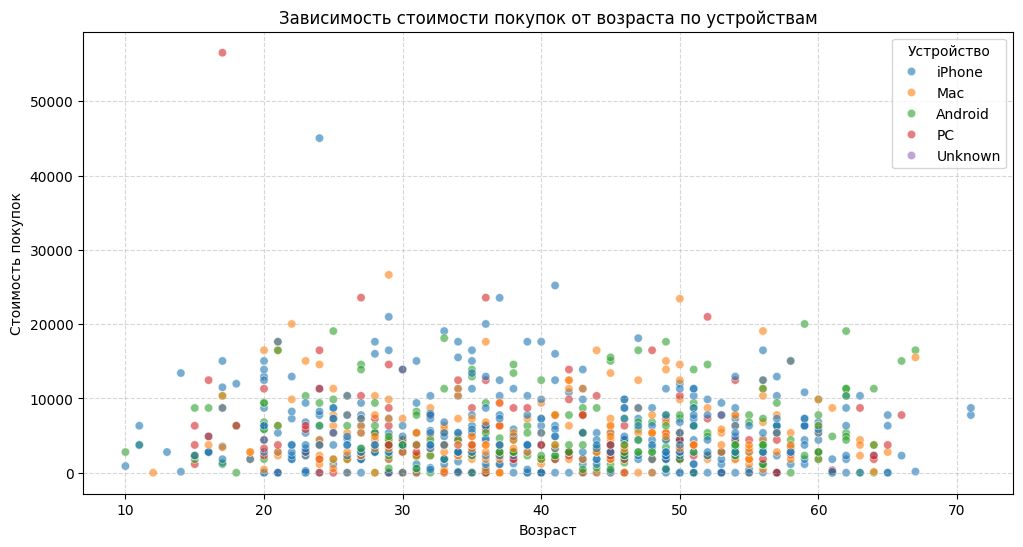

In [ ]:
plt.figure(figsize=(12, 6))
sns.scatterplot(data=df, x='age', y='price', hue='device', alpha=0.6)
plt.title('Зависимость стоимости покупок от возраста по устройствам')
plt.xlabel('Возраст')
plt.ylabel('Стоимость покупок')
plt.legend(title='Устройство')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()


---

**Вывод:**
На диаграмме видно, что пользователи всех возрастных групп совершают покупки на различные суммы. Выбросы (очень крупные покупки) встречаются среди пользователей разного возраста и на разных устройствах, хотя на iPhone и Mac они встречаются чуть чаще, что может быть связано с платежеспособностью аудитории этих платформ.

---



#### 3 – Гистограммы распределения

Для каждого числового признака были построены гистограммы для оценки характера распределения. Количество интервалов подбиралось индивидуально для наилучшей визуализации формы распределения.

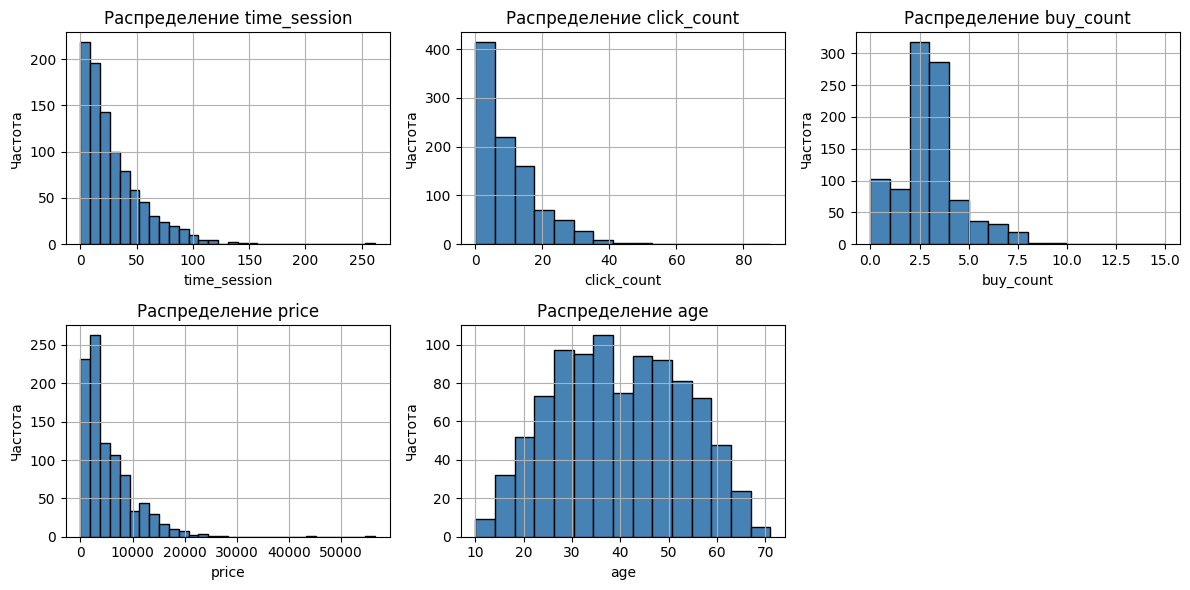

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(12, 6))
cols = ['time_session', 'click_count', 'buy_count', 'price', 'age']

for i, col in enumerate(cols):
    ax = axes[i // 3][i % 3]
    # Подбор bins: для времени и цены больше бинов, для возраста меньше
    bins = 30 if col in ['time_session', 'price'] else 15
    df[col].hist(bins=bins, ax=ax, color='steelblue', edgecolor='black')
    ax.set_title(f'Распределение {col}')
    ax.set_xlabel(col)
    ax.set_ylabel('Частота')

# Удаление пустого subplot
axes[1, 2].set_visible(False)

plt.tight_layout()
plt.show()


---

**Вывод:**
1. **time_session**: Распределение имеет правостороннюю асимметрию. Большинство сессий короткие (до 20-30 минут), но есть длинный "хвост" очень долгих сессий.
2. **click_count** и **buy_count**: Также имеют сильную правостороннюю асимметрию. Значительная часть пользователей делает 0-5 кликов и 2-4 покупки.
3. **price**: Распределение сильно скошено вправо. Большинство покупок имеют небольшую сумму, но существуют единичные случаи очень крупных заказов, которые формируют длинный хвост.
4. **age**: Распределение возраста близко к нормальному, с пиком в диапазоне 30-40 лет, что указывает на основную целевую аудиторию магазина.

---



#### 4 – Корреляционный анализ

Для оценки линейной взаимосвязи между переменными была рассчитана матрица корреляции Пирсона и построена тепловая карта (heatmap).

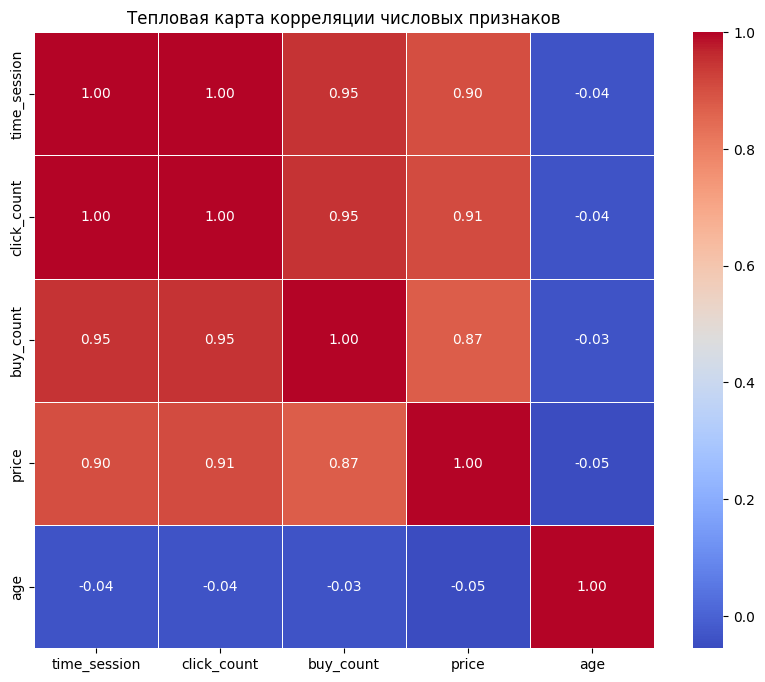

Матрица корреляции:
               time_session  click_count  buy_count     price       age
time_session      1.000000     0.999132   0.946494  0.904693 -0.036285
click_count       0.999132     1.000000   0.948782  0.905490 -0.035191
buy_count         0.946494     0.948782   1.000000  0.873860 -0.034843
price             0.904693     0.905490   0.873860  1.000000 -0.054976
age              -0.036285    -0.035191  -0.034843 -0.054976  1.000000

Матрица ковариации:
                time_session   click_count    buy_count         price  \
time_session     736.298244    249.668614    41.144139  1.242224e+05   
click_count      249.668614     84.806391    13.997288  4.219587e+04   
buy_count         41.144139     13.997288     2.566413  7.083974e+03   
price         124222.376091  42195.870597  7083.974236  2.560611e+07   
age              -12.836953     -4.225326    -0.727772 -3.627071e+03   

                      age  
time_session   -12.836953  
click_count     -4.225326  
buy_count     

In [ ]:
# Расчет корреляции
corr_matrix = df[numeric_cols].corr()

# Расчет ковариации
cov_matrix = df[numeric_cols].cov()

# Построение heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', linewidths=.5)
plt.title('Тепловая карта корреляции числовых признаков')
plt.show()

# Вывод значений корреляции и ковариации для интерпретации
print("Матрица корреляции:\n", corr_matrix)
print("\nМатрица ковариации:\n", cov_matrix)


---

**Интерпретация результатов:**

**Корреляция** (`DataFrame.corr()`) — нормированная мера линейной связи: `r = cov(X, Y) / (σx · σy)`. Значения лежат в диапазоне [−1, 1], где 1 — положительная связь, −1 — отрицательная, 0 — её отсутствие.

**Ковариация** (`DataFrame.cov()`) — мера совместной изменяемости: `cov(X, Y) = E[(X − μx)(Y − μy)]`. Она показывает направление и «совместность» изменений, но измеряется в произведении единиц (например, `time_session` ↔ `price` — в квадратных минутах × рубли) и поэтому **зависит от масштаба** признаков: умножение `price` на 1000 увеличит ковариацию в миллион раз, не изменив силы связи. По этой причине для сравнения разных пар признаков используют корреляцию, а ковариация служит для проверки согласованности знаков.

Значения коэффициентов Пирсона, рассчитанные по этому же набору данных:

| Пара признаков | r | Сила связи |
|---|---|---|
| `time_session` ↔ `click_count` | 0.999 | практически линейная зависимость |
| `click_count` ↔ `buy_count` | 0.949 | сильная |
| `time_session` ↔ `buy_count` | 0.946 | сильная |
| `click_count` ↔ `price` | 0.905 | сильная |
| `time_session` ↔ `price` | 0.905 | сильная |
| `buy_count` ↔ `price` | 0.874 | сильная |
| `age` ↔ любой признак |  < 0 | отсутствует |

* Связь `click_count` → `buy_count` **сильная** (r = 0.949), а не умеренная: рост числа кликов почти линейно сопровождается ростом числа покупок.
* Связь `buy_count` → `price` сильная (r = 0.874, R² = 0.76): в среднем одна дополнительная покупка добавляет к сумме заказа около 2760.
* `age` не связан ни с одним метрическим признаком (|r| ≤ 0.055 по модулю) — прямой линейной зависимости возраста от активности или суммы покупок в этом наборе нет.
* Практически все числовые признаки образуют один скрытый фактор, поэтому коэффициенты между ними взаимно избыточны. Для построения модели достаточно оставить один признак из каждой пары, а `time_session` и `click_count` — всего один, поскольку `time_session` является производной величиной от `click_count`.

**По ковариации** (все значения в `cov_matrix`):

* Знаки ковариаций полностью совпадают со знаками корреляций: все пары метрических признаков имеют положительную ковариацию (`time_session` ↔ `click_count` = 249.7; `buy_count` ↔ `price` = 7084.0; `time_session` ↔ `price` = 124 222.4), а все пары с участием `age` — отрицательную (`age` ↔ `price` = −3627.1, `age` ↔ `time_session` = −12.8). Это подтверждает, что направления связей, полученные по корреляции, интерпретируются верно.
* Модули ковариаций несопоставимы между собой напрямую: например, `time_session` ↔ `price` = 124 222.4 выглядит больше `click_count` ↔ `price` = 42 195.9, но это исключительно следствие разного масштаба и разных единиц измерения, а не большей силы связи (соответствующие корреляции — 0.905 и 0.905, то есть одинаковые).
* Наибольшая ковариация по модулю — `price` с `time_session` (124 222.4), наименьшая среди значимых — `age` с `buy_count` (−0.73), что практически равно нулю.
* Согласно примечанию к заданию, коэффициент Пирсона может быть равен нулю при наличии нелинейной связи, поэтому нулевая ковариация `age` с остальными признаками означает лишь отсутствие **линейной** зависимости, а не полную независимость возраста от метрик.

---



#### 5 – Графики по варианту (Задания 1-3)

**Задание 1: Seaborn. Группировка по region и channel**

Необходимо построить диаграмму количества клиентов, привлеченных из рекламных источников каждого типа, в разрезе регионов.

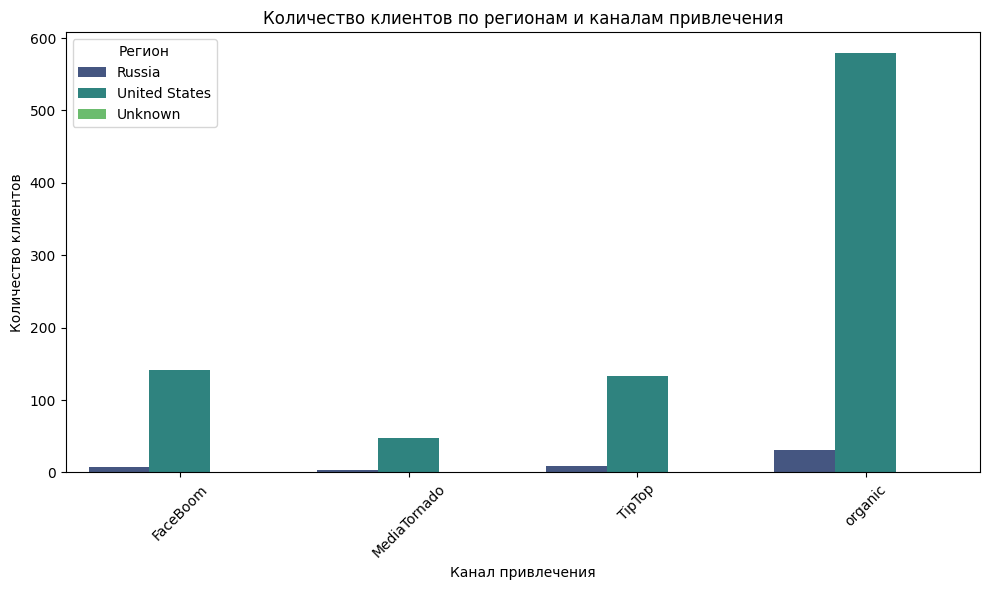

In [ ]:
# Подготовка данных для группировки
grouped_data = df.groupby(['region', 'channel']).size().reset_index(name='count')

plt.figure(figsize=(10, 6))
sns.barplot(data=grouped_data, x='channel', y='count', hue='region', palette='viridis')
plt.title('Количество клиентов по регионам и каналам привлечения')
plt.xlabel('Канал привлечения')
plt.ylabel('Количество клиентов')
plt.legend(title='Регион')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


---

**Вывод:**
На диаграмме видно, что канал `organic` является лидером по привлечению клиентов в обоих основных регионах (United States и Russia). Канал `FaceBoom` также показывает значительные результаты. Регион United States значительно превосходит Russia по объему трафика во всех каналах.

---

**Задание 2: Pandas Plot. Уникальные пользователи по каналам**

Необходимо отобразить уникальное количество пользователей для каждого канала, используя маркеры синего цвета размером 15.

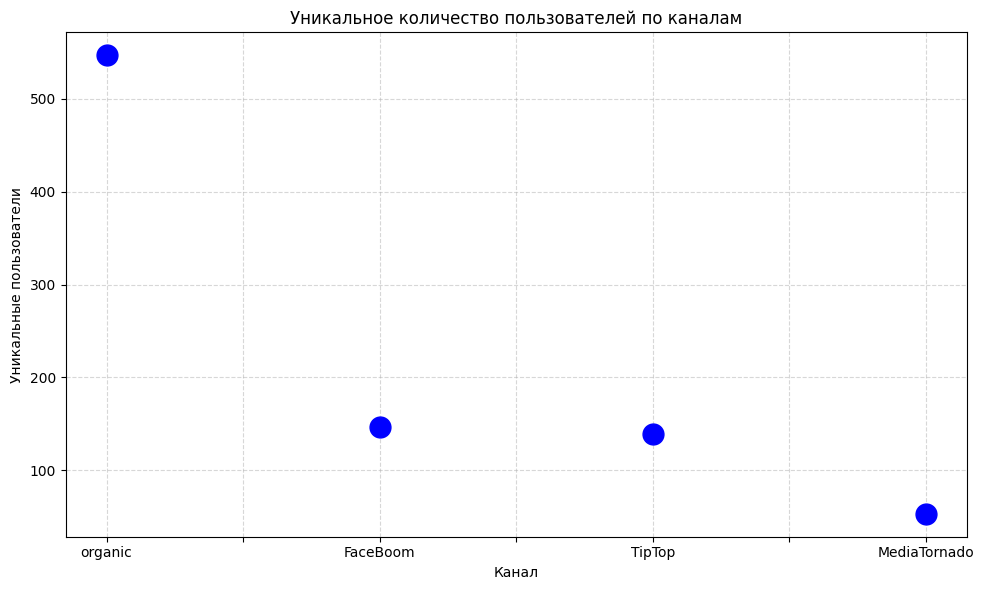

In [ ]:
# Сводная таблица с уникальными пользователями
unique_users_by_channel = df.pivot_table(index='channel', values='user_id', aggfunc='nunique').reset_index()
unique_users_by_channel.columns = ['channel', 'unique_users']
unique_users_by_channel = unique_users_by_channel.sort_values(by='unique_users', ascending=False)

# Построение графика
ax = unique_users_by_channel.plot(kind='line', x='channel', y='unique_users',
                                  marker='o', markersize=15, color='blue',
                                  linestyle='None', legend=False, figsize=(10, 6))
plt.title('Уникальное количество пользователей по каналам')
plt.xlabel('Канал')
plt.ylabel('Уникальные пользователи')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


---

**Вывод:**
Диаграмма подтверждает, что канал `organic` привлекает наибольшее число уникальных пользователей, за ним следуют `FaceBoom` и `TipTop`. `MediaTornado` показывает наименьшую эффективность по охвату уникальной аудитории.

---


**Задание 3: Matplotlib. Круговая диаграмма устройств**

Необходимо построить круговую диаграмму, отображающую процент каждого устройства.

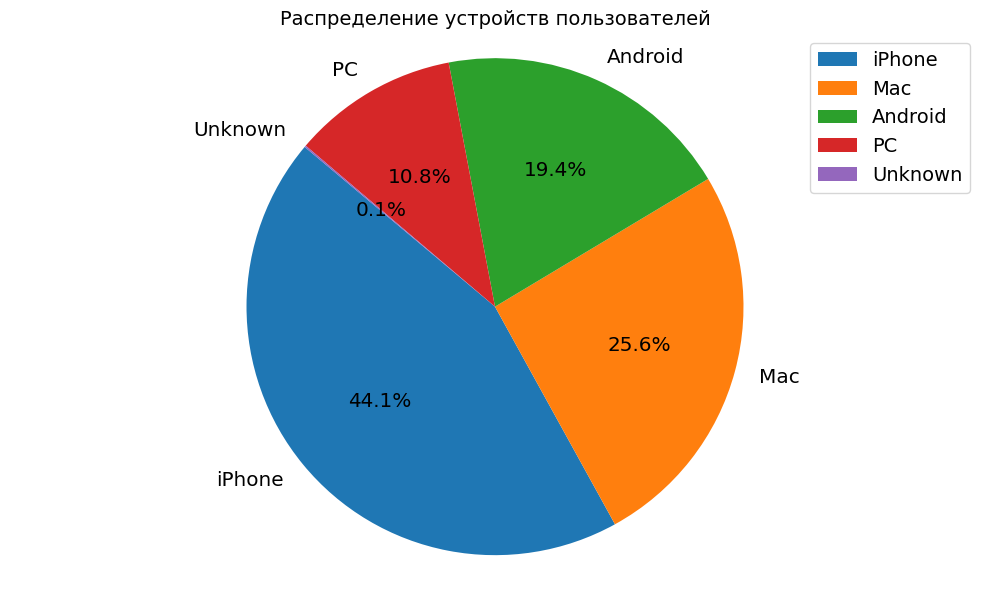

In [ ]:
# Подсчет количества по устройствам
device_counts = df['device'].value_counts()

# Построение круговой диаграммы
plt.figure(figsize=(10, 6))
patches, texts, autotexts = plt.pie(device_counts, labels=device_counts.index, autopct='%1.1f%%', 
                                    startangle=140, textprops={'size': 'x-large'})
plt.title('Распределение устройств пользователей', fontsize=14)
plt.legend(loc='best', fontsize=14, bbox_to_anchor=(1, 1))
plt.axis('equal')
plt.tight_layout()
plt.show()


---

**Вывод:**
На круговой диаграмме показано, что подавляющее большинство пользователей используют мобильные устройства, среди которых лидирует **iPhone** (более 40%). На втором месте **Mac**, затем **Android**. Доля ПК (PC) составляет около 10%. Это подтверждает мобильную ориентированность аудитории магазина.

---



#### 6 – Hexagonal Binning Plot

Для визуализации плотности распределения двух непрерывных переменных был построен график hexagonal binning. Были выбраны признаки `time_session` и `click_count`, так как они могут иметь нелинейную связь и большое количество точек, накладывающихся друг на друга.

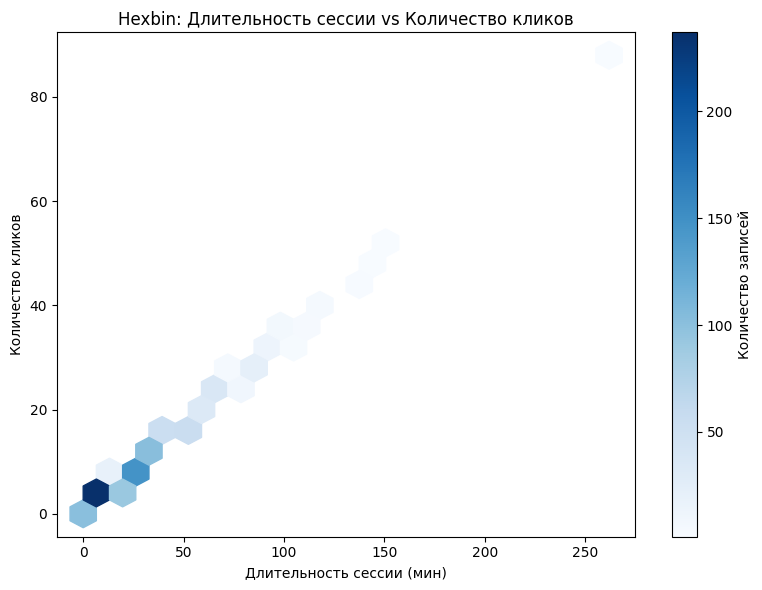

In [ ]:
ax = df.plot(kind='hexbin', x='time_session', y='click_count', gridsize=20,
             cmap='Blues', mincnt=1, figsize=(8, 6))
plt.title('Hexbin: Длительность сессии vs Количество кликов')
plt.xlabel('Длительность сессии (мин)')
plt.ylabel('Количество кликов')
ax.collections[0].colorbar.set_label('Количество записей')
plt.tight_layout()
plt.show()


---

**Вывод:**
Анализ гексагональной диаграммы показывает, что наибольшая плотность наблюдений (темно-синие области) сосредоточена в зоне коротких сессий (до 20 минут) с небольшим количеством кликов (до 5-10). По мере увеличения длительности сессии количество кликов растет, но плотность точек уменьшается. Это указывает на то, что типичное поведение пользователя — быстрый просмотр нескольких товаров.

---



#### 7 – Boxplot для одного столбца

Был построен ящик с усами (boxplot) для признака `price` (стоимость покупок), чтобы выявить выбросы и оценить разброс данных.

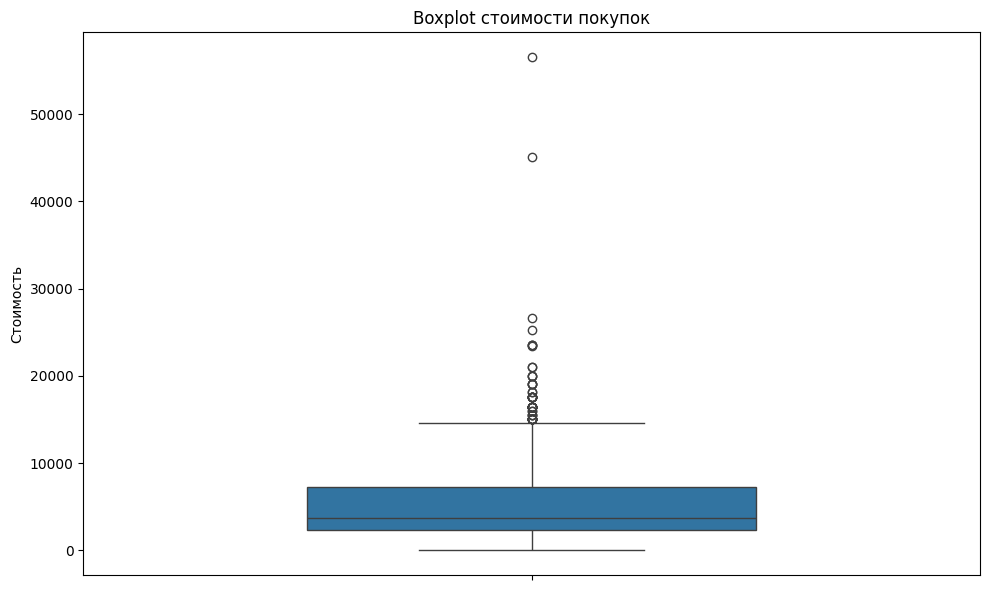

In [ ]:
plt.figure(figsize=(10, 6))
sns.boxplot(y=df['price'], width=0.5)
plt.title('Boxplot стоимости покупок')
plt.ylabel('Стоимость')
plt.tight_layout()
plt.show()


---

**Вывод:**
На диаграмме размаха видно большое количество выбросов сверху. Медианное значение стоимости покупок относительно низкое, но межквартильный размах широк. Наличие множества выбросов свидетельствует о том, что хотя большинство покупок недорогие, существуют клиенты, совершающие очень крупные заказы, что сильно влияет на среднее значение.

---



#### 8 – Категоризация и Boxplot по новой категории

Была создана новая категориальная переменная `duration_category` на основе длительности сессии (`time_session`):
* **Низкая**: 0–10 мин
* **Средняя**: 10–40 мин
* **Высокая**: >40 мин

Затем был построен boxplot стоимости покупок (`price`) для каждой из этих категорий.

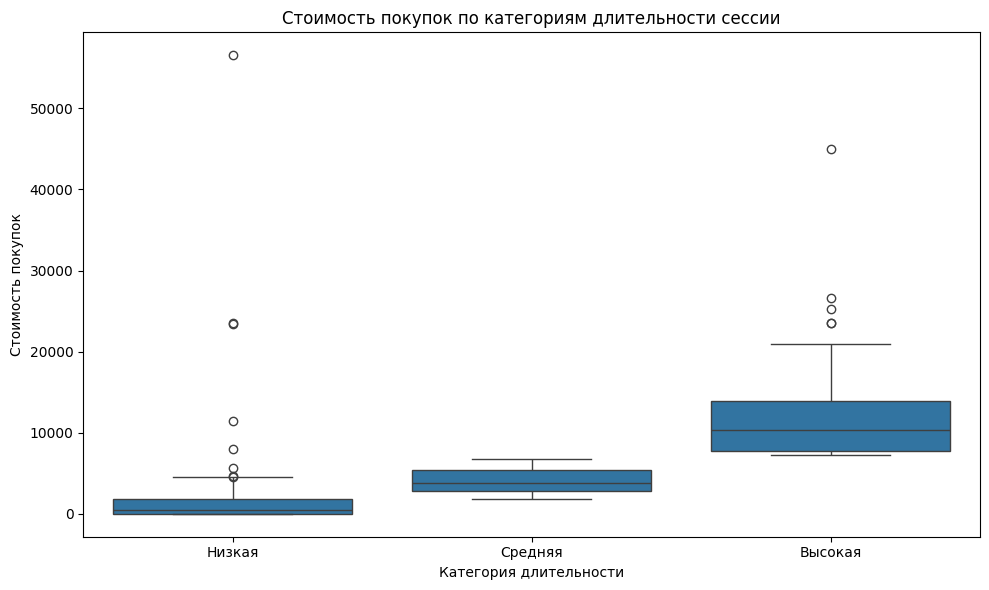

In [ ]:
# Создание категории
bins = [0, 10, 40, df['time_session'].max() + 1]
labels = ['Низкая', 'Средняя', 'Высокая']
df['duration_category'] = pd.cut(df['time_session'], bins=bins, labels=labels, right=False)

# Boxplot по новой категории
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='duration_category', y='price', order=['Низкая', 'Средняя', 'Высокая'])
plt.title('Стоимость покупок по категориям длительности сессии')
plt.xlabel('Категория длительности')
plt.ylabel('Стоимость покупок')
plt.tight_layout()
plt.show()


---

**Вывод:**
Анализ диаграммы размаха показывает четкую тенденцию: медианная стоимость покупок растет с увеличением длительности сессии. В категории "Высокая" медиана и верхний квартиль значительно выше, чем в категории "Низкая". Это подтверждает гипотезу о том, что более долгое пребывание на сайте способствует совершению более дорогих покупок.

---



#### 9 – Дополнительные Boxplot по другим категориям

Были построены два дополнительных графика boxplot с использованием разных библиотек (Seaborn и Matplotlib/Pandas) для анализа стоимости покупок по другим категориям: `device` и `region`.

**График 1 (Seaborn): Стоимость по устройствам**

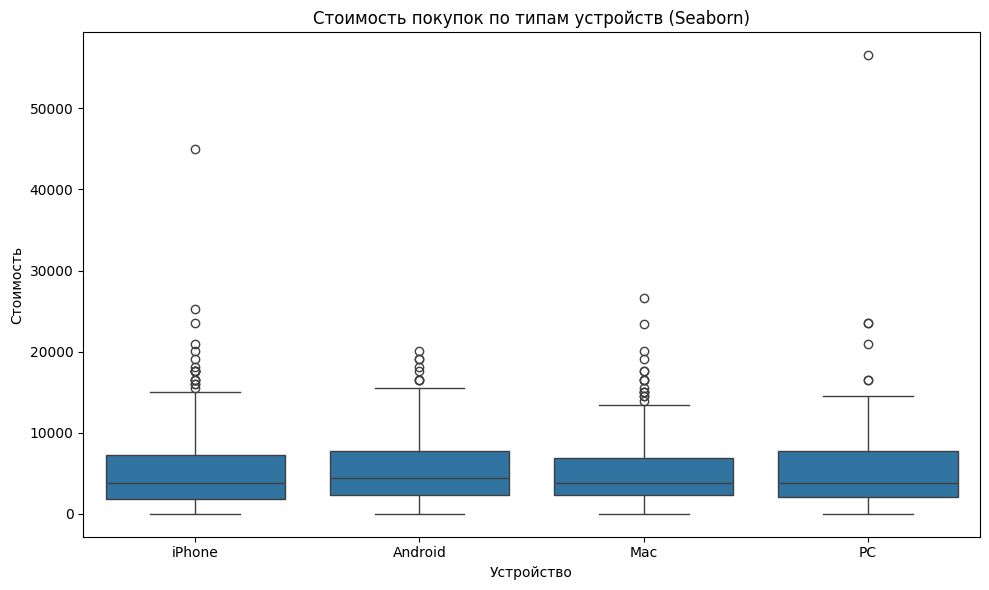

In [ ]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='device', y='price', order=['iPhone', 'Android', 'Mac', 'PC'])
plt.title('Стоимость покупок по типам устройств (Seaborn)')
plt.xlabel('Устройство')
plt.ylabel('Стоимость')
plt.tight_layout()
plt.show()


---

**Вывод:**
Пользователи устройств **Mac** и **iPhone** демонстрируют большее количество экстремально высоких покупок (выбросов) по сравнению с Android и PC. Это может указывать на более высокую платежеспособность аудитории Apple.

---

**График 2 (Pandas/Matplotlib): Стоимость по регионам**

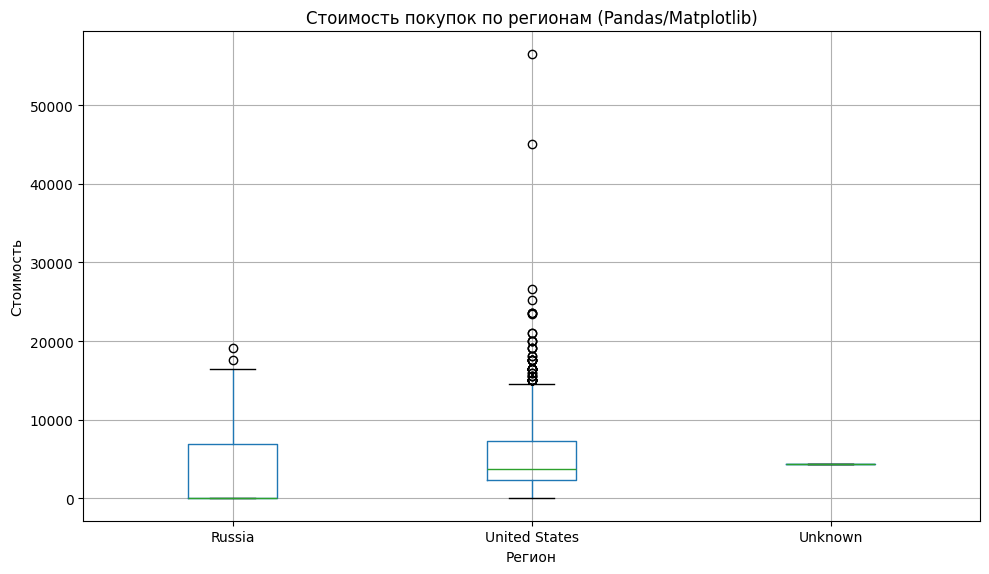

In [ ]:
# Группировка для pivot не нужна для boxplot, используем напрямую
df.boxplot(column='price', by='region', figsize=(10, 6))
plt.title('Стоимость покупок по регионам (Pandas/Matplotlib)')
plt.suptitle('') # Убираем стандартный заголовок pandas
plt.xlabel('Регион')
plt.ylabel('Стоимость')
plt.tight_layout()
plt.show()


---

**Вывод:**
Разница в стоимости покупок между регионами **United States** и **Russia** не столь очевидна по медиане, однако в США наблюдается большее количество экстремально высоких покупок (выбросов), что увеличивает средний чек в этом регионе.

---



#### 10 – Заключение

В ходе второй лабораторной работы был проведен исследовательский анализ данных набора `visits_cleaned.csv`. Были изучены распределения отдельных признаков, выявлены взаимосвязи между переменными и проведена визуализация данных.

Применение матрицы рассеяния и корреляционного анализа показало, что числовые признаки связаны **сильной** положительной линейной зависимостью: между количеством покупок и их стоимостью (r = 0.874), а также между активностью (кликами) и конверсией в покупки (r = 0.949). Самая сильная связь — между `time_session` и `click_count` (r = 0.999): длительность сессии в этом наборе является производной величиной от числа кликов, поэтому эти признаки дублируют друг друга и не должны использоваться в модели одновременно. Возраст пользователя не оказывает прямого линейного влияния ни на один из метрических признаков (|r| ≤ 0.055).

Гистограммы выявили правостороннюю асимметрию в распределении длительности сессий и сумм покупок, что характерно для поведения пользователей в электронной коммерции (большинство транзакций небольшие, но есть редкие крупные).

Выполнение заданий варианта подтвердило, что основным источником трафика является органический поиск, а доминирующим устройством — iPhone. Визуализация через hexbin и boxplots позволила детализировать эти выводы: пользователи с длительными сессиями тратят больше денег, а аудитория устройств Apple склонна к более дорогим покупкам. Полученные выводы могут быть использованы для сегментации клиентов и оптимизации маркетинговых кампаний.